# Agrupamiento de Jugadores por Perfil de Habilidad (K-Medias)

Reproduce la Seccion 4.3 del informe: K-Medias sobre 24 atributos de rendimiento de campo de `player_attributes`. Se excluyen los arqueros (gk_diving >= 30) y se toma una muestra aleatoria de 20.000 registros (random_state=42) de los 166.432 jugadores elegibles, con estandarizacion z-score previa.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / ".git").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root / "src"))

import pandas as pd
from mineria.data_loader import load_table
from mineria.clustering import player_cluster_data, standardize, kmeans_scores, fit_kmeans, profile_means, closest_to_centroids
from mineria.plots import radar_profiles, elbowa_plot
%matplotlib inline

In [2]:
df, cols = player_cluster_data(load_table("Player_Attributes"))
print("Muestra de jugadores:", len(df))
X = standardize(df, cols)

Muestra de jugadores: 20000


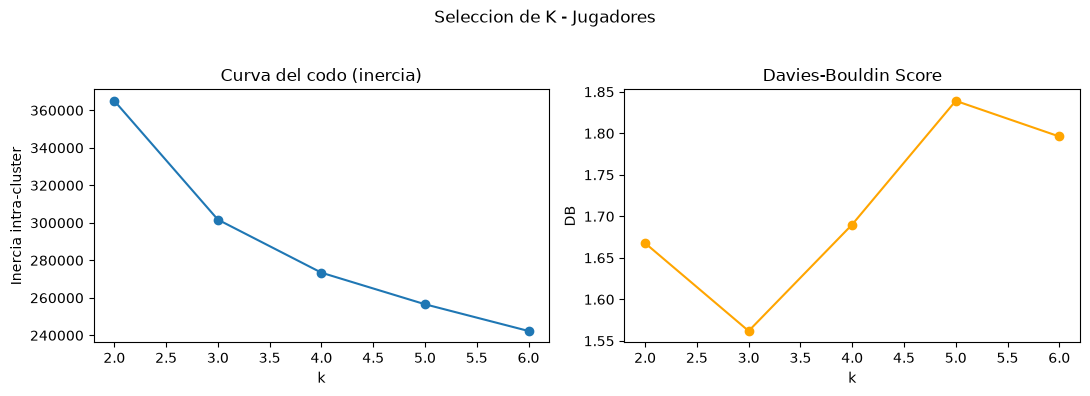

In [3]:
scores = kmeans_scores(X, range(2, 7))
scores.round(3)
elbowa_plot(scores, "Seleccion de K - Jugadores");

In [4]:
km = fit_kmeans(X, 3)
df["cluster"] = km.labels_
df["cluster"].value_counts().sort_index()

cluster
0    7831
1    5643
2    6526
Name: count, dtype: int64

In [5]:
sel = ["finishing", "short_passing", "dribbling", "marking", "standing_tackle", "sprint_speed", "stamina", "vision", "interceptions"]
profile_means(df, km, cols).loc[sel].round(1)

cluster,0,1,2
finishing,66.0,33.7,53.5
short_passing,64.9,58.0,72.6
dribbling,70.1,47.7,67.5
marking,27.8,62.3,63.3
standing_tackle,31.6,64.9,68.3
sprint_speed,74.4,62.6,71.4
stamina,66.2,65.3,76.5
vision,63.0,48.2,67.3
interceptions,36.8,61.6,68.2


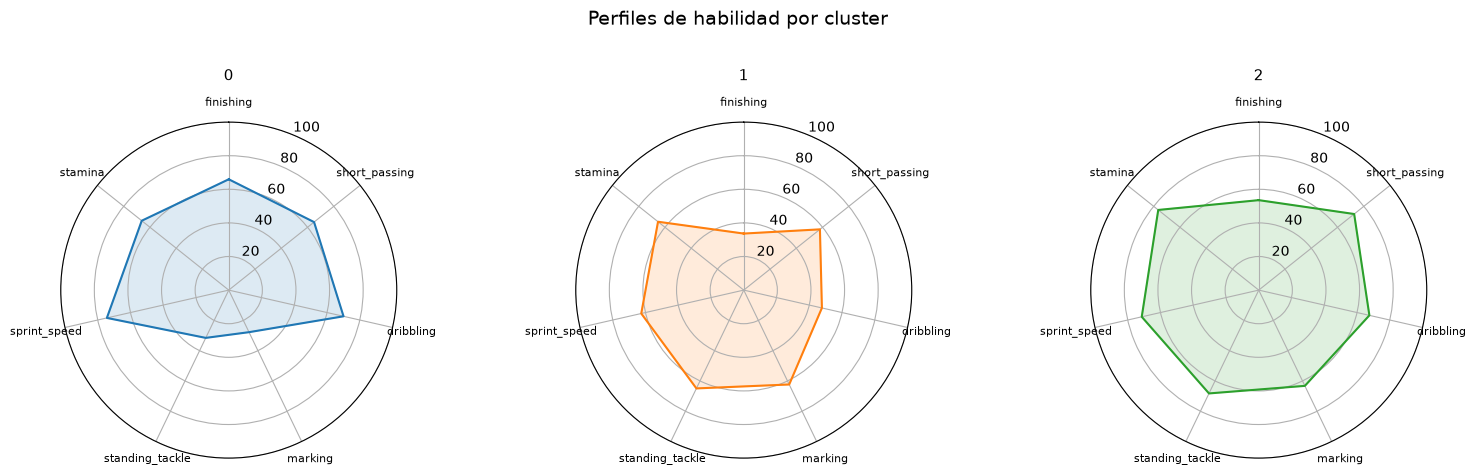

In [6]:
sub = ["finishing", "short_passing", "dribbling", "marking", "standing_tackle", "sprint_speed", "stamina"]
radar_profiles(profile_means(df, km, cols).loc[sub], "Perfiles de habilidad por cluster");

In [7]:
representativos = closest_to_centroids(df, X, km)
player = load_table("Player")
representativos = representativos.merge(player[["player_api_id", "player_name"]], on="player_api_id", how="left")
representativos[["cluster", "player_name"]]

,cluster,player_name
0,0,Stefan Nijland
1,1,Ryan McGivern
2,2,Daniele Dessena


## Interpretacion

- **Defensor (n~5.8k, 29%)**: valores bajos en remate (finishing) y regate, altos en marca (marking) y entrada firme (standing_tackle).
- **Mediocampista (n~6.5k, 33%)**: mayor pase corto (short_passing) y valores intermedios en ataque y defensa. Jugadores bisagra.
- **Delantero (n~7.7k, 38%)**: mayor remate (finishing), regate y vision de juego, con marca y entrada firme muy bajos.

El algoritmo reproduce las tres posiciones fundamentales del futbol sin recibir informacion de posicion, confirmando la solidez interpretativa del agrupamiento.